In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
import PIL
import cv2
import shutil
import kagglehub
import random

In [2]:
# os.environ['KAGGLEHUB_CACHE'] = '/content/'

In [3]:
KPATH = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")
KPATH = os.path.join(KPATH, 'PetImages')
print(KPATH)

Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.
/kaggle/input/microsoft-catsvsdogs-dataset/PetImages


In [4]:
shutil.copytree(KPATH, '/content/PetImages')

'/content/PetImages'

In [5]:
KPATH = '/content/PetImages'
assert  os.path.exists(KPATH)

In [6]:
# !sudo chmod -R 777 '/kaggle/input/microsoft-catsvsdogs-dataset/PetImages'

In [7]:
# (train_ds,), dinfo = tfds.load(
#     name='cats_vs_dogs',
#     split=['train[:80]','train[80%:]'],
#     with_info=True,
#     as_supervised=True,
#     shuffle_files=True
#     )

In [8]:
LABELS=['Cat', 'Dog']
IMAGE_SIZE=(152, 152)
BATCH_SIZE = 32
# [*train_ds.take(2)]

In [9]:
for f in os.listdir(os.path.join(KPATH, 'Dog')):
  try:
    PIL.Image.open(os.path.join(KPATH, 'Dog', f))
  except Exception as e:
    print(f, e)
    os.remove(os.path.join(KPATH, 'Dog', f))

for f in os.listdir(os.path.join(KPATH, 'Cat')):
  try:
    PIL.Image.open(os.path.join(KPATH, 'Cat', f))
  except Exception as e:
    print(f, e)
    os.remove(os.path.join(KPATH, 'Cat', f))


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


11702.jpg cannot identify image file '/content/PetImages/Dog/11702.jpg'
Thumbs.db cannot identify image file '/content/PetImages/Dog/Thumbs.db'
Thumbs.db cannot identify image file '/content/PetImages/Cat/Thumbs.db'
666.jpg cannot identify image file '/content/PetImages/Cat/666.jpg'


In [10]:
cat_files = random.sample(os.listdir(os.path.join(KPATH, 'Cat'))[:50], 10)
dog_files = random.sample(os.listdir(os.path.join(KPATH, 'Dog'))[:50], 10)

In [11]:
fig, axs = plt.subplots(4, 5, figsize=(20,20))
axs = axs.flatten()
i = 0
for fc, fd in zip(cat_files, dog_files):
    fc = os.path.join(KPATH, 'Cat', fc)
    fd = os.path.join(KPATH, 'Dog', fd)
    axs[i].imshow(cv2.imread(fc, cv2.IMREAD_COLOR_RGB))
    axs[i].set_title('Cat')
    i += 1
    axs[i].imshow(cv2.imread(fd, cv2.IMREAD_COLOR_RGB))
    axs[i].set_title('Dog')
    i += 1
plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [12]:
#tf.keras.utils.image_dataset_from_directory(KPATH...)new method
# data agumentation using ImageDataGenerator(DEPRECATED)
train_data_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255,
    rotation_range=20, #rotated by an angle b/w -20 to 20
    shear_range=0.2, #skewing
    horizontal_flip=True,
    validation_split=0.2,
)

test_data_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255,
    validation_split=0.2,
)
#why 2 image generator? because test data not require agumentation

In [13]:
train_gen = train_data_gen.flow_from_directory (
  KPATH,
  target_size=(152, 152),
  batch_size=32,
  class_mode='binary', #'categorical'
  subset='training',
  seed=42
)

test_gen = test_data_gen.flow_from_directory(
    KPATH,
    target_size=(152, 152),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    seed=42
)

# instead of using flow_from_directory function,
# data_gen.fit(train_data) and data_gen.flow(train_data) can be used as alternative

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [14]:
# model = tf.keras.models.Sequential()

# model.add(tf.keras.layers.Conv2D(filters=32,
#     kernel_size=(3,3),
#     strides=1,
#     padding='valid',
#     activation='relu'))
# model.add(tf.keras.layers.BatchNormalization())
# model.add(tf.keras.layers.MaxPooling2D(2,2))

# model.add(tf.keras.layers.Conv2D(
#     filters=64,
#     kernel_size=(3,3),
#     strides=1,
#     padding='valid', # or 'sample'
#     activation='relu'
#     ))
# model.add(tf.keras.layers.BatchNormalization())
# model.add(tf.keras.layers.MaxPooling2D(2,2))


# model.add(tf.keras.layers.Conv2D(
#   filters=128,
#   kernel_size=(3,3),
#   strides=1,
#   padding='valid',
#   activation='relu',
# ))
# model.add(tf.keras.layers.BatchNormalization())
# model.add(tf.keras.layers.MaxPooling2D(2,2)) #down sampling

# model.add(tf.keras.layers.Flatten())
# model.add(tf.keras.layers.Dense(units=512,
#                                 activation=tf.keras.activations.leaky_relu,
#                                 # regularizer=tf.keras.regularizers.l2
#                                 ))
# model.add(tf.keras.layers.Dropout(0.25))
# model.add(tf.keras.layers.Dense(units=1,
#                                 activation=tf.keras.activations.sigmoid))


In [15]:
# # ?tf.keras.optimizers.Adam
# #compile model - (basic ex: With Stochastic Gradient Descent optimizer using MSE as loss)
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), #RMSProp() #SGD
#     loss=tf.keras.losses.binary_crossentropy,
#     metrics=['accuracy']
# )

In [16]:
# ?model.fit

In [17]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',),#input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(2,activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    train_gen,
    validation_data=test_gen,
    # steps_per_epoch = 150, #batches of samples
    epochs=3
    )

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 150s 231ms/step - accuracy: 0.6136 - loss: 0.6712 - val_accuracy: 0.6767 - val_loss: 0.6084
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 221ms/step - accuracy: 0.6866 - loss: 0.5947 - val_accuracy: 0.7233 - val_loss: 0.5619
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 135s 217ms/step - accuracy: 0.7307 - loss: 0.5417 - val_accuracy: 0.7461 - val_loss: 0.5238


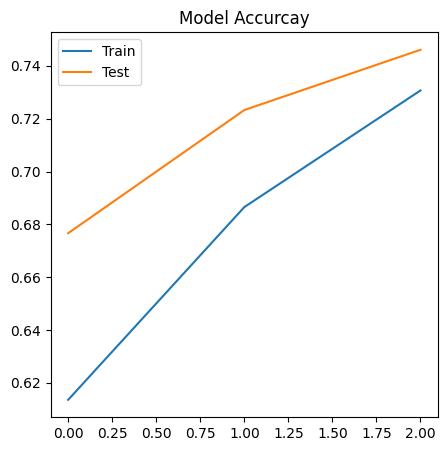

In [19]:
plt.figure(figsize=(5,5))
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.legend(['Train', 'Test'])
plt.title('Model Accurcay')
plt.show()

In [20]:
# evaluate
test_loss, test_acc = model.evaluate(test_gen, verbose=2)

157/157 - 8s - 48ms/step - accuracy: 0.7461 - loss: 0.5238


In [21]:
# model.predict(im_array)

NameError: name 'im_array' is not defined

In [1]:
#prediction
fpath = os.path.join(KPATH, 'Cat', random.sample(cat_files, 1)[0])
im_array = cv2.imread(fpath, cv2.IMREAD_COLOR_RGB)
plt.imshow(im_array)
# print(im_array.shape)
im_array = tf.expand_dims(cv2.resize(im_array, IMAGE_SIZE) / 255, axis=0)
# print(im_array.shape)
LABELS[model.predict(im_array).argmax()]

NameError: name 'os' is not defined